<a href="https://colab.research.google.com/github/murathany27/nbiot-channel/blob/main/ntn_advanced_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zaman Analizi
Bu notebook `zaman_analizi.py` dosyasından oluşturulmuştur. Colab üzerinde çalıştırmak için öncelikle gerekli kütüphaneleri yükleyin.

In [ ]:
!pip install ephem sgp4 astropy itur matplotlib numpy skyfield

  Using cached ephem-4.2.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.3 kB)
  Using cached sgp4-2.25-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (33 kB)
  Using cached itur-0.4.0-py2.py3-none-any.whl.metadata (7.0 kB)
  Using cached skyfield-1.54-py3-none-any.whl.metadata (2.4 kB)
  Using cached jplephem-2.24-py3-none-any.whl.metadata (24 kB)
Using cached ephem-4.2.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.8 MB)
Using cached sgp4-2.25-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (235 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00


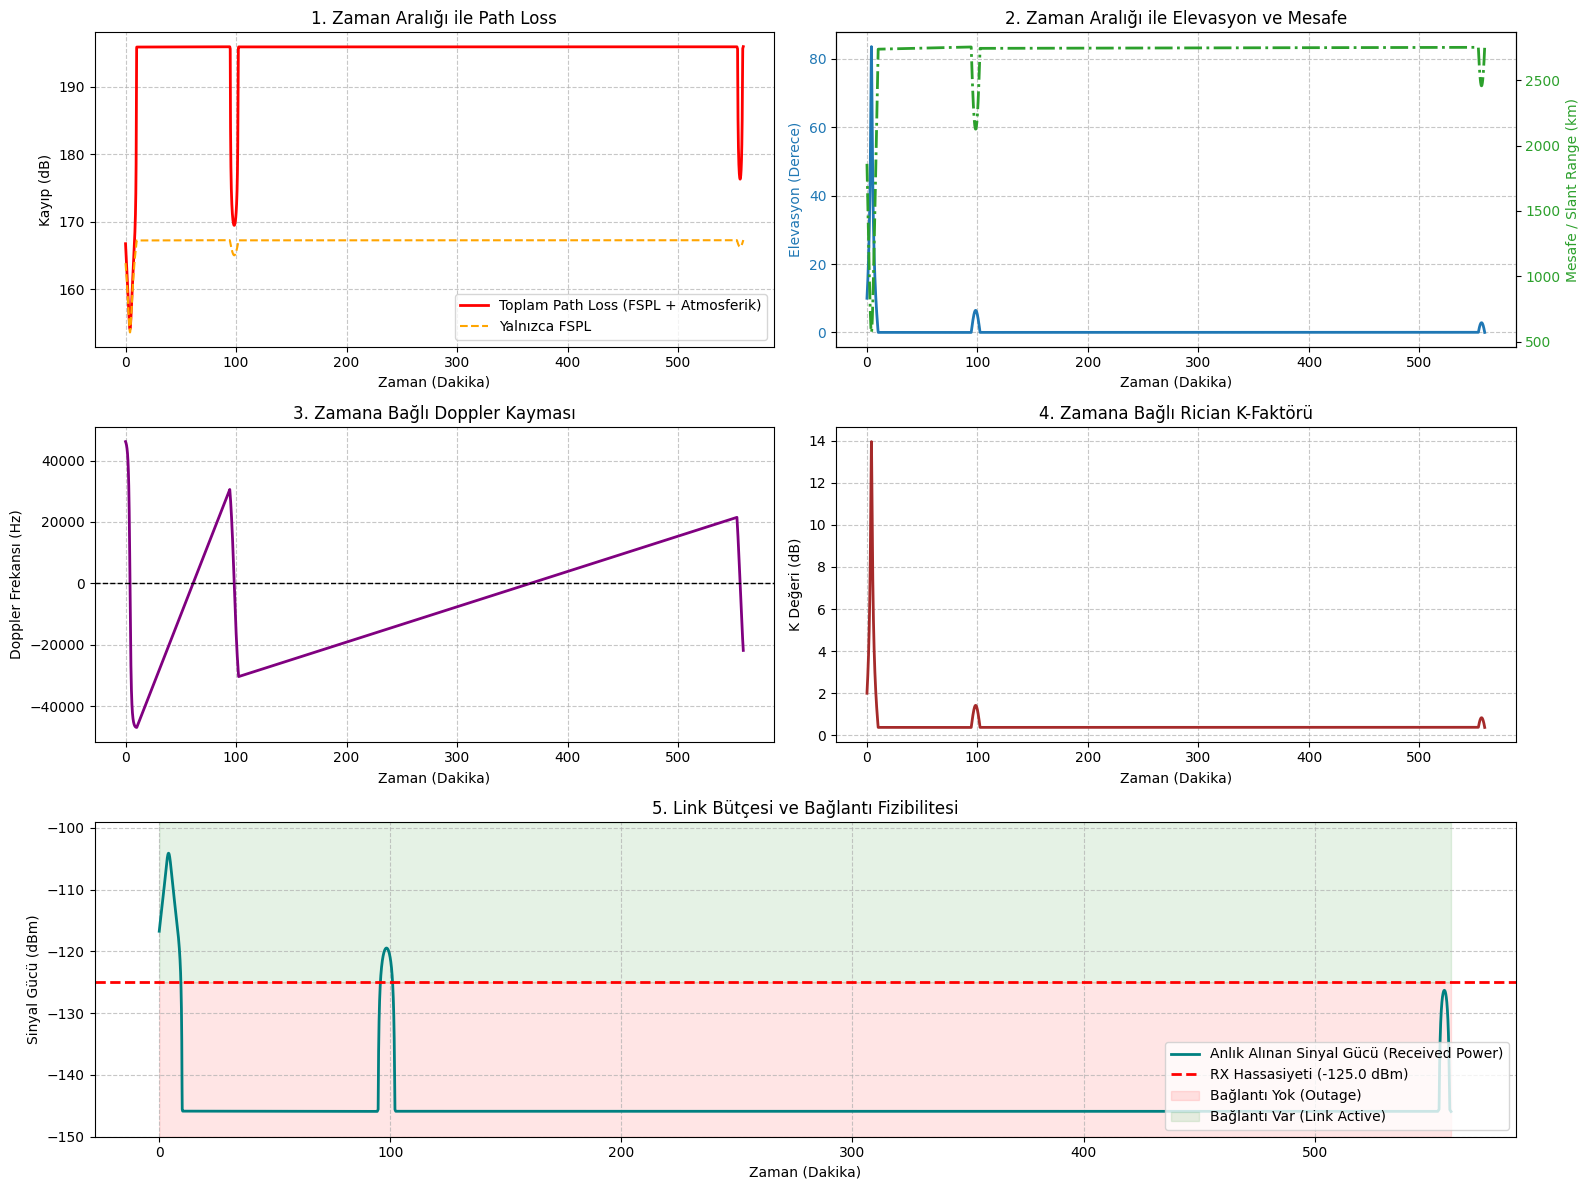

In [25]:
# @title

import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import load, EarthSatellite, wgs84
from datetime import timedelta
from matplotlib.gridspec import GridSpec

# ==========================================
# ITU-R Kütüphanesi Yükleme Denemesi
# ==========================================

ITUR_AVAILABLE = False

#try:
#    import itur
#    import itur.models.itu525 as itu525
#    from itur.models.itu676 import gaseous_attenuation_slant_path as itu676 # Değişiklik burada
#    ITUR_AVAILABLE = True
#    print("[BİLGİ] 'itur' kütüphanesi başarıyla yüklendi. Hesaplamalar ITU-R modelleri ile yapılacak.")
#except ImportError:
#    print("---------------------------------------------------------")
#    print("[UYARI] 'itur' kütüphanesi bulunamadı!")
#    print("Hesaplamalar matematiksel formüller (channel.py standardı) ile yapılacaktır.")
#    print("ITU-R modellerini aktif etmek için terminalden şu komutu çalıştırın:")
#    print("pip install itur")
#    print("---------------------------------------------------------")
#    ITUR_AVAILABLE = False

# ==========================================
# BAŞLANGIÇ: ZAMAN VE UYDU TANIMLAMA
# ==========================================
ts = load.timescale()
t_now = ts.now()

# channel.py'deki TLE verileri
tle_line1 = '1 52755U 22057AH  24128.50000000  .00000000  00000-0  00000-0 0  9997'
tle_line2 = '2 52755  97.5000 150.0000 0010000   0.0000 360.0000 15.00000000100000'

# Uydu ve yer istasyonunu oluştur
satellite = EarthSatellite(tle_line1, tle_line2, 'CONNECTA', ts)
station_lat = 39.9208
station_lon = 32.8541
ground_station = wgs84.latlon(station_lat, station_lon)

# --- UYDU GEÇİŞİNİ BULMA (ZAMAN ARALIĞI) ---
t_future = ts.from_datetime(t_now.utc_datetime() + timedelta(days=7))
pass_times, pass_events = satellite.find_events(ground_station, t_now, t_future, altitude_degrees=10.0)

# SADECE 0 (Doğuş / Rise) olaylarını filtrele
rise_indices = [i for i, event in enumerate(pass_events) if event == 0]

if len(rise_indices) > 0:
    idx = rise_indices[0] # İlk geçişin doğuş indeksi
    t_start = pass_times[idx]

    # Batış (set) anı, skyfield diziliminde doğuştan 2 indeks sonradır (0 -> 1 -> 2)
    # Garanti olması için 2 indeks sonrasının gerçekten '2' (batış) olup olmadığını kontrol ediyoruz
    if idx + 2 < len(pass_times) and pass_events[idx + 2] == 2:
        t_end = pass_times[idx + 2]
    else:
        # Eğer bir hata olur da batış bulunamazsa yedek süre ekle
        t_end = ts.from_datetime(t_start.utc_datetime() + timedelta(minutes=15))
else:
    print("[BİLGİ] Uydu geçişi bulunamadı. Varsayılan 10 dakikalık aralık kullanılıyor.")
    t_start = t_now
    t_end = ts.from_datetime(t_now.utc_datetime() + timedelta(minutes=10))

# ==========================================
# HESAPLAMA DONGUSU (ZAMAN SERİSİ)
# ==========================================
# İlgili değişkenler
carrier_freq_mhz = 2000
carrier_freq_ghz = carrier_freq_mhz / 1000.0
carrier_freq_hz = carrier_freq_mhz * 1e6
c_km_s = 299792.458

# Link Budget (Bağlantı Bütçesi) sabitleri
tx_power_dbm = 30.0 # Uydu gönderim gücü (Örn: 30 dBm = 1 Watt)
tx_gain_dbi = 20.0  # Uydu anten kazancı
rx_gain_dbi = 0.0   # Telsiz/Cihaz anten kazancı
rx_sensitivity_dbm = -125.0 # Telsiz alma hassasiyeti (NB-IoT için tipik)

# Sonuç dökümleri
time_minutes_list = []
elevation_list = []
distance_list = []
doppler_list = []
fspl_list = []
total_path_loss_list = []
k_factor_list = []
link_budget_list = []

for s in range(total_seconds):
    current_t = ts.from_datetime(t_start.utc_datetime() + timedelta(seconds=s))

    # 1. Geometri ve Elevasyon/Mesafe
    diff = satellite - ground_station
    alt, az, dist = diff.at(current_t).altaz()
    el_deg = alt.degrees
    d_km = dist.km

    # Elevasyon < 0 ise veriyi kaydetme, sadece görünen kısımları al
    if el_deg < 0:
        continue

    # Dakika cinsinden zamanı kaydet (başlangıç 0 olacak şekilde)
    time_minutes_list.append(s / 60.0)
    elevation_list.append(el_deg)
    distance_list.append(d_km)

    # 2. Doppler Kayması
    t_next = ts.from_datetime(current_t.utc_datetime() + timedelta(seconds=1))
    d_next = diff.at(t_next).distance().km
    v_rel = d_km - d_next # Yaklaşıyorsa mesafe azalır, hız (+) çıkar
    doppler_hz = (v_rel / c_km_s) * carrier_freq_hz
    doppler_list.append(doppler_hz)

    # 3. Path Loss & Atmosferik Kayıp (ITU-R)
    fspl = 0
    atm_loss = 0
    if ITUR_AVAILABLE:
        try:
            # ITU-R P.525 Free Space Loss
            # (Eğer model object dönerse `.value` ile çek, sayıysa direkt kullan)
            val = itu525.free_space_loss(d_km, carrier_freq_ghz)
            fspl = float(val.value) if hasattr(val, 'value') else float(val)
        except Exception:
            fspl = 32.44 + 20 * np.log10(d_km) + 20 * np.log10(carrier_freq_mhz)

        try:
            # ITU-R P.676 Slant Path Gaseous Attenuation
            # rho=7.5 g/m3 (su buharı), P=1013.25 hPa (basınç), T=15 C (Sıcaklık)
            val_atm = itu676(carrier_freq_ghz, el_deg, 7.5, 1013.25, 15.0) # Fonksiyon çağrısı güncellendi
            atm_loss = float(val_atm.value) if hasattr(val_atm, 'value') else float(val_atm)
        except Exception:
            atm_loss = 0.5 / np.sin(np.radians(max(el_deg, 1.0)))
    else:
        # channel.py modeline fallback
        fspl = 32.44 + 20 * np.log10(d_km) + 20 * np.log10(carrier_freq_mhz)
        atm_loss = 0.5 / np.sin(np.radians(max(el_deg, 1.0)))

    total_loss = fspl + atm_loss
    fspl_list.append(fspl)
    total_path_loss_list.append(total_loss)

    # 4. Rician K Değeri
    # channel.py'deki dağılıma göre
    k_db = min(15.0, 2.0 + ((el_deg - 10) / 80) * 13.0)
    k_factor_list.append(k_db)

    # 5. Link Bütçesi
    # Received Power (dBm) = TxPower(dBm) + TxGain(dBi) + RxGain(dBi) - TotalPathLoss(dB)
    rx_power = tx_power_dbm + tx_gain_dbi + rx_gain_dbi - total_loss
    link_budget_list.append(rx_power)


# ==========================================
# GRAFİKLERİ ÇİZME
# ==========================================
# Verileri numpy dizisine çevirme
time_arr = np.array(time_minutes_list)
el_arr = np.array(elevation_list)
dist_arr = np.array(distance_list)
dop_arr = np.array(doppler_list)
fspl_arr = np.array(fspl_list)
loss_arr = np.array(total_path_loss_list)
k_arr = np.array(k_factor_list)
lb_arr = np.array(link_budget_list)

fig = plt.figure(figsize=(16, 12))
fig.canvas.manager.set_window_title('NTN Zaman Serisi ve Senaryo Analizi (ITU-R Destekli)')
gs = GridSpec(3, 2, figure=fig)

# -- 1. Grafik: Path Loss vs Zaman --
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_arr, loss_arr, label='Toplam Path Loss (FSPL + Atmosferik)', color='red', linewidth=2)
ax1.plot(time_arr, fspl_arr, linestyle='--', label='Yalnızca FSPL', color='orange')
ax1.set_title('1. Zaman Aralığı ile Path Loss')
ax1.set_xlabel('Zaman (Dakika)')
ax1.set_ylabel('Kayıp (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# -- 2. Grafik: Elevasyon ve Mesafe vs Zaman --
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xlabel('Zaman (Dakika)')
ax2.set_ylabel('Elevasyon (Derece)', color='tab:blue')
ax2.plot(time_arr, el_arr, color='tab:blue', linewidth=2, label='Elevasyon')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True, linestyle='--', alpha=0.7)

ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('Mesafe / Slant Range (km)', color='tab:green')
ax2_twin.plot(time_arr, dist_arr, linestyle='-.', color='tab:green', linewidth=2, label='Mesafe')
ax2_twin.tick_params(axis='y', labelcolor='tab:green')
plt.title('2. Zaman Aralığı ile Elevasyon ve Mesafe')

# -- 3. Grafik: Doppler vs Zaman --
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_arr, dop_arr, color='purple', linewidth=2)
ax3.set_title('3. Zamana Bağlı Doppler Kayması')
ax3.set_xlabel('Zaman (Dakika)')
ax3.set_ylabel('Doppler Frekansı (Hz)')
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.grid(True, linestyle='--', alpha=0.7)

# -- 4. Grafik: K Faktörü vs Zaman --
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_arr, k_arr, color='brown', linewidth=2)
ax4.set_title('4. Zamana Bağlı Rician K-Faktörü')
ax4.set_xlabel('Zaman (Dakika)')
ax4.set_ylabel('K Değeri (dB)')
ax4.grid(True, linestyle='--', alpha=0.7)

# -- 5. Grafik: Link Bütçesi (Received Power) vs Zaman --
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(time_arr, lb_arr, color='teal', linewidth=2, label='Anlık Alınan Sinyal Gücü (Received Power)')
ax5.axhline(rx_sensitivity_dbm, color='red', linestyle='--', linewidth=2, label=f'RX Hassasiyeti ({rx_sensitivity_dbm} dBm)')

# Grafiğin arka planına bağlantı koptu / devam ediyor uyarısı koyma (Opsiyonel görselleştirme)
ax5.fill_between(time_arr, -150, rx_sensitivity_dbm, color='red', alpha=0.1, label='Bağlantı Yok (Outage)')
ax5.fill_between(time_arr, rx_sensitivity_dbm, np.max(lb_arr)+5, color='green', alpha=0.1, label='Bağlantı Var (Link Active)')

ax5.set_title('5. Link Bütçesi ve Bağlantı Fizibilitesi')
ax5.set_xlabel('Zaman (Dakika)')
ax5.set_ylabel('Sinyal Gücü (dBm)')
ax5.set_ylim(-150, np.max(lb_arr)+5)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='lower right')

plt.tight_layout()
plt.show()

# NTN Advanced Channel Simulator
Bu notebook `ntn_advanced_simulator.py` dosyasından oluşturulmuştur. Colab üzerinde çalıştırmak için öncelikle gerekli kütüphaneleri yükleyin.

In [ ]:
!pip install ephem sgp4 astropy itur matplotlib numpy


--- GEÇİŞ BULUNDU ---
Başlangıç: 2026-04-21 22:49:13.538147 UTC
Bitiş: 2026-04-21 23:00:55.847045 UTC
Maksimum Elevasyon: 45.5 Derece
Simülasyon hesaplanıyor, lütfen bekleyin... (Bu işlem gelişmiş fizik hesaplamaları nedeniyle birkaç saniye sürebilir)
Simülasyon tamamlandı! Dashboard hazırlanıyor...


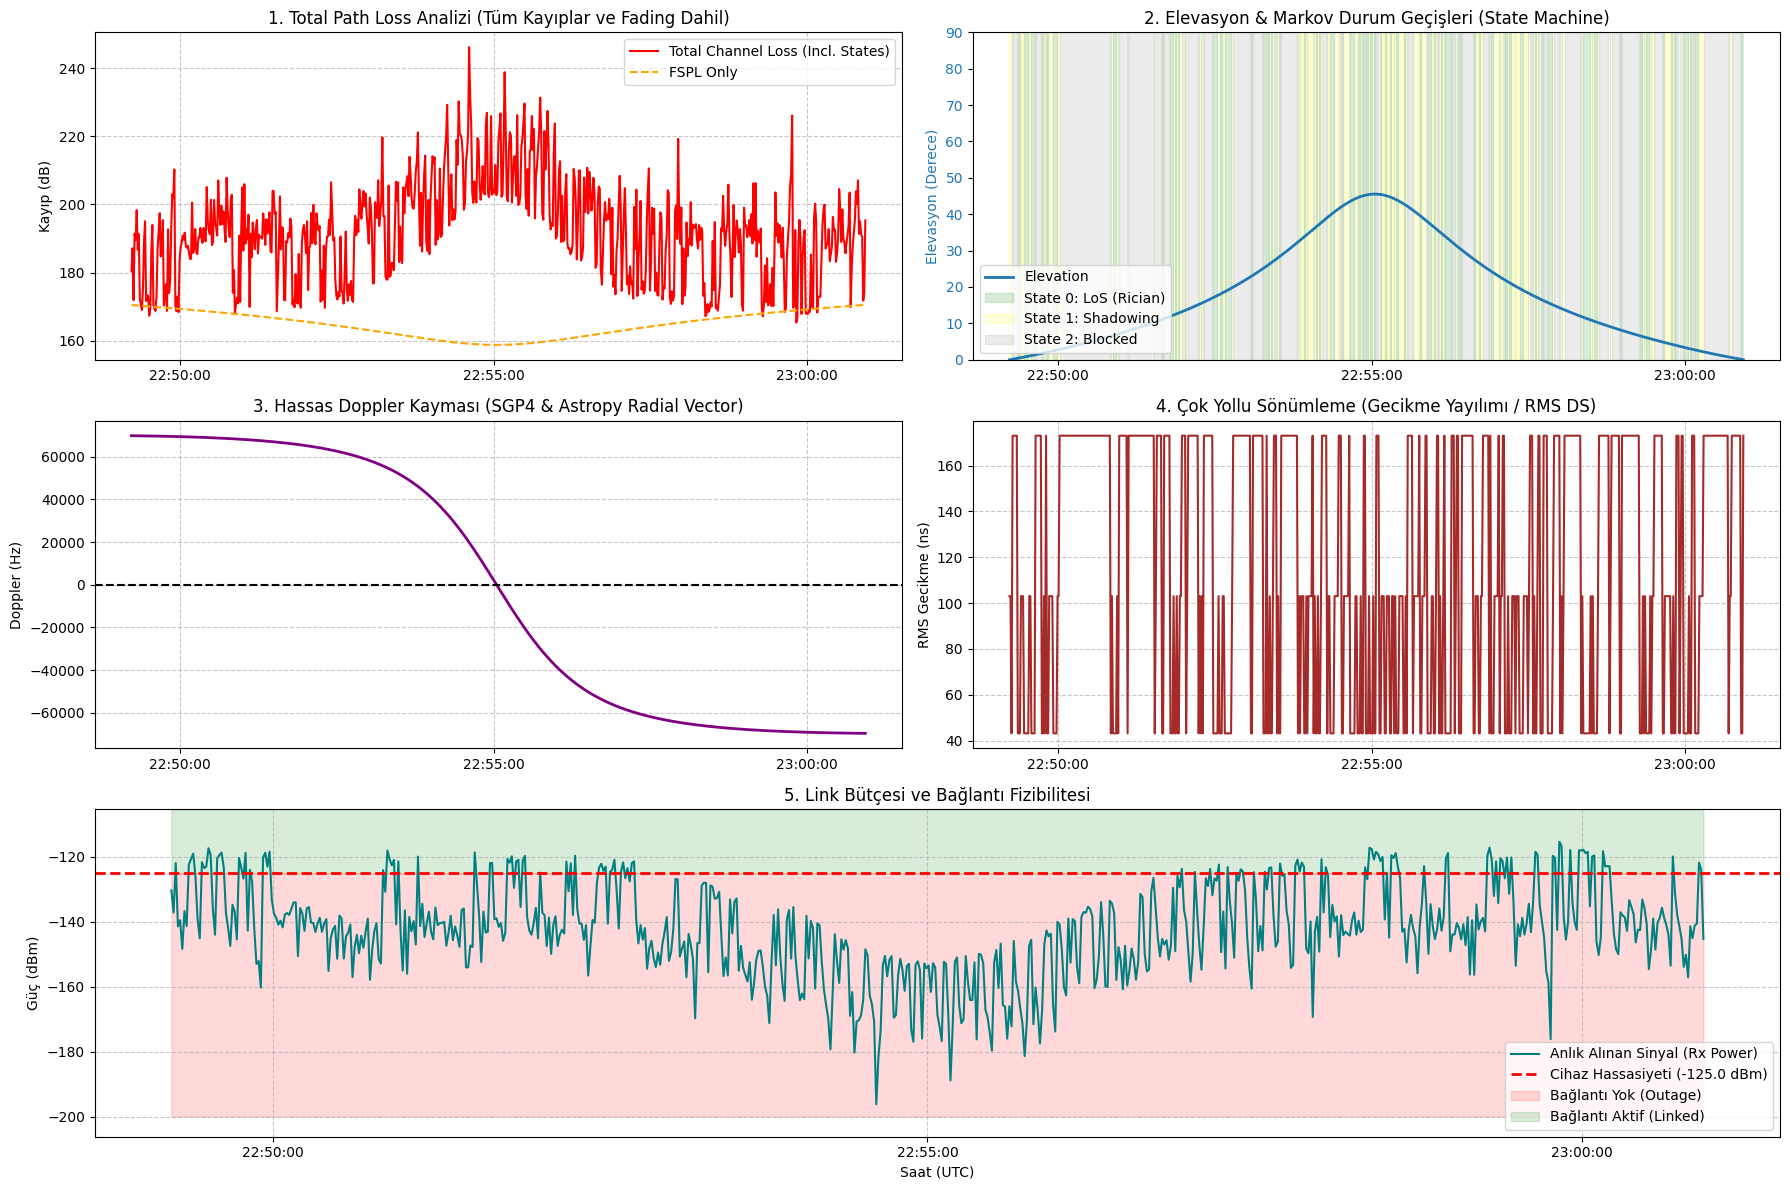

In [ ]:
# @title
import numpy as np
from datetime import datetime, timedelta
import collections
import warnings

# ==========================================
# GEREKLİ KÜTÜPHANELER
# ==========================================
# Uydu ve Yörünge Fiziği
import ephem
from sgp4.api import Satrec, SGP4_ERRORS
from astropy.time import Time
from astropy import units as u
from astropy.coordinates import TEME, ITRS, EarthLocation, CartesianRepresentation, CartesianDifferential

# ITU-R Zayıflama Modelleri
from itur.models.itu676 import gaseous_attenuation_slant_path
from itur.models.itu618 import rain_attenuation, scintillation_attenuation
from itur.models.itu840 import cloud_attenuation

# Görselleştirme
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# Astropy uyarılarını konsolu kirletmemesi için gizliyoruz
warnings.filterwarnings('ignore')

# ==========================================
# 1. PARAMETRE SETİ (Kullanıcı + Bizim Parametreler)
# ==========================================
c = 299792458.0 # Işık hızı (m/s)

# Yer İstasyonu (Ankara Örneği)
gs_lat_deg = 39.9
gs_lon_deg = 32.8
gs_h_km = 0.850 # 850m rakım

station = ephem.Observer()
station.lat, station.lon = str(gs_lat_deg), str(gs_lon_deg)
station.elevation = gs_h_km * 1000.0

# Frekans ve Hava Durumu İstatistikleri
f_ghz = 3.0
f_hz = f_ghz * 1e9

T_k = 293.15      # Sıcaklık (Kelvin)
P_hpa = 1013.25   # Basınç (hPa)
rho_gm3 = 7.5     # Su buharı yoğunluğu
p = 0.01          # Yıllık olasılık
D = 0.6           # Anten Çapı (m) - Sintilasyon

# Link Bütçesi (Örnek NB-IoT NTN Değerleri)
tx_power_dbm = 30.0    # Uydu Gönderim Gücü (1 Watt)
tx_gain_dbi = 20.0     # Uydu Anten Kazancı
rx_gain_dbi = 0.0      # Alıcı (Telsiz) Anteni
rx_sensitivity_dbm = -125.0 # Telsizin koptuğu alt sınır

# Uydu Bilgileri (TLE)
tle_l1 = "1 64555U 25135AD  26106.74795786  .00001933  00000+0  92239-4 0  9993"
tle_l2 = "2 64555  97.4610 222.4026 0001997 124.5460 235.5964 15.20264790 45526"

sat = ephem.readtle("CONNECTA IOT-10", tle_l1, tle_l2)
sat_sgp4 = Satrec.twoline2rv(tle_l1, tle_l2)

# ==========================================
# 2. FİZİKSEL KATMAN VE KANAL FONKSİYONLARI
# ==========================================
state_names = {0: "LoS (Rician)", 1: "Shadowing (Log-Normal)", 2: "Blocked (Rayleigh)"}

# Gölgeleme Değişkenleri
shadow_corr_db = 0.0
shadow_rho = 0.985
num_paths = 3
initial_path_phase = 2 * np.pi * np.random.rand(num_paths)

def get_small_scale_loss(state):
    if state == 0:
        K = 10**(10/10)
        r = np.sqrt(K/(K+1)) + np.sqrt(1/(K+1)) * (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r))
    elif state == 1:
        r = (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r)) + 4.0
    else:
        r = (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r)) + 20.0

def get_transition_matrix(theta):
    theta_clamped = max(0, min(theta, 90))
    p_stay_los = 0.5 + 0.45 * (theta_clamped / 90)
    p_stay_blocked = 0.9 - 0.4 * (theta_clamped / 90)
    P = np.array([
        [p_stay_los, (1 - p_stay_los) * 0.8, (1 - p_stay_los) * 0.2],
        [0.3, 0.4, 0.3],
        [1 - p_stay_blocked, 0.0, p_stay_blocked]
    ])
    return P / P.sum(axis=1, keepdims=True)

def update_correlated_shadow(prev_shadow_db, theta, state):
    if state == 1:
        mu = 8.0 - (max(theta, 0.0) / 90.0) * 4.0
        innovation = np.random.normal(0.0, 3.0) # Sigma = 3.0
        new_shadow = shadow_rho * prev_shadow_db + np.sqrt(1 - shadow_rho**2) * innovation
        return mu + new_shadow
    else:
        return 0.0

def get_path_profile(state):
    if state == 0:
        excess_delays_s = np.array([0.0, 80e-9, 220e-9])
        rel_powers_db = np.array([0.0, -8.0, -15.0])
    elif state == 1:
        excess_delays_s = np.array([0.0, 120e-9, 350e-9])
        rel_powers_db = np.array([0.0, -5.0, -9.0])
    else:
        excess_delays_s = np.array([0.0, 180e-9, 500e-9])
        rel_powers_db = np.array([0.0, -3.0, -6.0])
    rel_powers_lin = 10**(rel_powers_db / 10.0)
    rel_powers_lin = rel_powers_lin / np.sum(rel_powers_lin)
    return excess_delays_s, rel_powers_lin

def get_path_dopplers(theta, base_doppler_hz):
    theta_clamped = max(0.0, min(theta, 90.0))
    spread_scale = (90.0 - theta_clamped) / 90.0
    max_extra_spread_hz = 250.0 * spread_scale
    offsets = np.array([0.0, max_extra_spread_hz, -max_extra_spread_hz])
    return base_doppler_hz + offsets

def build_tdl_channel(state, theta, base_doppler_hz, t_rel_s, propagation_delay_s):
    excess_delays_s, rel_powers_lin = get_path_profile(state)
    path_dopplers_hz = get_path_dopplers(theta, base_doppler_hz)
    abs_delays_s = propagation_delay_s + excess_delays_s
    mean_delay = np.sum(rel_powers_lin * abs_delays_s)
    rms_delay_spread_s = np.sqrt(np.sum(rel_powers_lin * (abs_delays_s - mean_delay)**2))
    coherence_bw_hz = 1.0 / (5.0 * rms_delay_spread_s) if rms_delay_spread_s > 0 else np.inf
    return abs_delays_s, path_dopplers_hz, rms_delay_spread_s, coherence_bw_hz

def doppler(satrec_obj, obs_time_dt, gs_lat_deg, gs_lon_deg, gs_h_km, f_hz):
    t = Time(obs_time_dt)
    error_code, teme_p, teme_v = satrec_obj.sgp4(t.jd1, t.jd2)
    if error_code != 0: raise RuntimeError(SGP4_ERRORS[error_code])
    teme_p = CartesianRepresentation(teme_p * u.km)
    teme_v = CartesianDifferential(teme_v * u.km / u.s)
    teme = TEME(teme_p.with_differentials(teme_v), obstime=t)
    itrs_geo = teme.transform_to(ITRS(obstime=t))
    gs = EarthLocation.from_geodetic(lon=gs_lon_deg*u.deg, lat=gs_lat_deg*u.deg, height=gs_h_km*u.km)
    sat_pos = itrs_geo.cartesian.without_differentials().xyz.to(u.km).value
    sat_vel = itrs_geo.cartesian.differentials['s'].d_xyz.to(u.km/u.s).value
    gs_pos = gs.get_itrs(t).cartesian.xyz.to(u.km).value
    los_vec = sat_pos - gs_pos
    los_hat = los_vec / np.linalg.norm(los_vec)
    radial_velocity_m_s = np.dot(sat_vel, los_hat) * 1000.0
    return -radial_velocity_m_s / c * f_hz

def find_best_pass(observer, satellite, search_hours=24):
    original_date = observer.date
    best_pass, best_alt_deg = None, -1.0
    end_date = ephem.Date(observer.date + search_hours * ephem.hour)
    while observer.date < end_date:
        info = observer.next_pass(satellite)
        if None in (info[0], info[2], info[4]): break
        max_alt = np.degrees(float(info[3]))
        if max_alt > best_alt_deg:
            best_alt_deg = max_alt
            best_pass = info
        observer.date = ephem.Date(info[4] + ephem.minute)
    observer.date = original_date
    return best_pass

# ==========================================
# 3. YÖRÜNGE ARAMA VE SİMÜLASYON DÖNGÜSÜ
# ==========================================
station.date = datetime.utcnow()
best_pass = find_best_pass(station, sat, search_hours=24)

if best_pass is None:
    raise RuntimeError("Geçerli bir uydu geçişi bulunamadı.")

rise_time, rise_az, max_time, max_alt, set_time, set_az = best_pass
analysis_start_dt = rise_time.datetime()
analysis_end_dt = set_time.datetime()

print(f"--- GEÇİŞ BULUNDU ---")
print(f"Başlangıç: {analysis_start_dt} UTC")
print(f"Bitiş: {analysis_end_dt} UTC")
print(f"Maksimum Elevasyon: {np.degrees(float(max_alt)):.1f} Derece")

# Zaman çözünürlüğü: Dinamik grafikler için 1 saniye
time_step_seconds = 1

# Veri toplama listeleri
data = collections.defaultdict(list)

station.date = rise_time
current_state = 0

print("Simülasyon hesaplanıyor, lütfen bekleyin... (Bu işlem gelişmiş fizik hesaplamaları nedeniyle birkaç saniye sürebilir)")
while station.date < set_time:
    sat.compute(station)
    theta = np.degrees(float(sat.alt))
    dist_km = float(sat.range) / 1000.0
    current_dt = station.date.datetime()
    t_rel_s = (current_dt - analysis_start_dt).total_seconds()

    # Sadece ufuk üzerindeki değerleri değerlendir
    if theta < 0:
        current_state = 2
    else:
        Pm = get_transition_matrix(theta)
        current_state = np.random.choice([0, 1, 2], p=Pm[current_state])

    # Free Space Path Loss (ITU-R P.525 Mantığı)
    fspl_db = 20 * np.log10(dist_km) + 20 * np.log10(f_ghz * 1000.0) + 32.44

    # ITUR Zayıflamaları (Gaz, Yağmur, Bulut, Sintilasyon)
    if theta > 5:
        try:
            gas_db = float(gaseous_attenuation_slant_path(f=f_ghz, el=theta, rho=rho_gm3, P=P_hpa, T=T_k, h=gs_h_km, mode='approx').value)
            rain_db = float(rain_attenuation(gs_lat_deg, gs_lon_deg, f_ghz, theta, p).value)
            cloud_db = float(cloud_attenuation(gs_lat_deg, gs_lon_deg, f_ghz, theta, p).value)
            scint_db = float(scintillation_attenuation(gs_lat_deg, gs_lon_deg, f_ghz, theta, p, D).value)
            atm_db = gas_db + rain_db + cloud_db + scint_db
        except Exception:
            atm_db = 0.5 / np.sin(np.radians(max(theta, 1.0)))
    else:
        atm_db = 0.0

    shadow_corr_db = update_correlated_shadow(shadow_corr_db, theta, current_state)
    small_scale_db = get_small_scale_loss(current_state)

    # Hassas Doppler (Astropy Radial Vector)
    doppler_hz = doppler(sat_sgp4, current_dt, gs_lat_deg, gs_lon_deg, gs_h_km, f_hz)

    # Link Bütçesi
    total_loss_db = fspl_db + atm_db + shadow_corr_db + small_scale_db
    rx_power = tx_power_dbm + tx_gain_dbi + rx_gain_dbi - total_loss_db

    # Yayılım gecikmesi (Delay Spread) TDL Channel
    prop_delay_s = (dist_km * 1000.0) / c
    abs_delays, path_dopps, rms_ds, coherence_bw = build_tdl_channel(
        current_state, theta, doppler_hz, t_rel_s, prop_delay_s)

    # Veri Kaydı
    data['time'].append(current_dt)
    data['theta'].append(theta)
    data['dist'].append(dist_km)
    data['fspl'].append(fspl_db)
    data['atm'].append(atm_db)
    data['loss'].append(total_loss_db)
    data['doppler'].append(doppler_hz)
    data['state'].append(current_state) # 0, 1, 2
    data['rx_power'].append(rx_power)
    data['rms_ds_ns'].append(rms_ds * 1e9)

    # Gecikmeyi 1 Saniye olarak ileri atlat
    station.date += ephem.second * time_step_seconds

print("Simülasyon tamamlandı! Dashboard hazırlanıyor...")

# ==========================================
# 4. PROFESYONEL GÖRSELLEŞTİRME (DASHBOARD)
# ==========================================
time_arr = np.array(data['time'])
rx_arr = np.array(data['rx_power'])
theta_arr = np.array(data['theta'])
state_arr = np.array(data['state'])

fig = plt.figure(figsize=(18, 12))
fig.canvas.manager.set_window_title('NTN Advanced Channel Emulator Dashboard (SGP4 + Markov Fading)')
gs = GridSpec(3, 2, figure=fig)

# -- 1. Path Loss & Atmosphere --
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_arr, data['loss'], label='Total Channel Loss (Incl. States)', color='red')
ax1.plot(time_arr, data['fspl'], '--', label='FSPL Only', color='orange')
ax1.set_title('1. Total Path Loss Analizi (Tüm Kayıplar ve Fading Dahil)')
ax1.set_ylabel('Kayıp (dB)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# -- 2. Elevation & State Transitions --
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_arr, theta_arr, color='tab:blue', linewidth=2, label='Elevation')
ax2.set_ylabel('Elevasyon (Derece)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Arka planda Markov State boyamaları
ax2.fill_between(time_arr, 0, 90, where=(state_arr==0), color='green', alpha=0.15, label='State 0: LoS (Rician)')
ax2.fill_between(time_arr, 0, 90, where=(state_arr==1), color='yellow', alpha=0.15, label='State 1: Shadowing')
ax2.fill_between(time_arr, 0, 90, where=(state_arr==2), color='gray', alpha=0.15, label='State 2: Blocked')

ax2.set_title('2. Elevasyon & Markov Durum Geçişleri (State Machine)')
ax2.set_ylim(0, 90)
ax2.legend(loc='lower left')

# -- 3. Doppler Kayması (Astropy Radial Vector) --
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_arr, data['doppler'], color='purple', linewidth=2)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title('3. Hassas Doppler Kayması (SGP4 & Astropy Radial Vector)')
ax3.set_ylabel('Doppler (Hz)')
ax3.grid(True, linestyle='--', alpha=0.7)

# -- 4. Gecikme Yayılımı (RMS Delay Spread) --
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_arr, data['rms_ds_ns'], color='brown')
ax4.set_title('4. Çok Yollu Sönümleme (Gecikme Yayılımı / RMS DS)')
ax4.set_ylabel('RMS Gecikme (ns)')
ax4.grid(True, linestyle='--', alpha=0.7)

# -- 5. Link Budget (Kopma Kontrolü) --
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(time_arr, rx_arr, color='teal', linewidth=1.5, label='Anlık Alınan Sinyal (Rx Power)')
ax5.axhline(rx_sensitivity_dbm, color='red', linestyle='--', linewidth=2, label=f'Cihaz Hassasiyeti ({rx_sensitivity_dbm} dBm)')

# Başarı ve kopma alanlarının boyanması
ax5.fill_between(time_arr, -200, rx_sensitivity_dbm, color='red', alpha=0.15, label='Bağlantı Yok (Outage)')
ax5.fill_between(time_arr, rx_sensitivity_dbm, max(rx_arr)+10, color='green', alpha=0.15, label='Bağlantı Aktif (Linked)')

ax5.set_title('5. Link Bütçesi ve Bağlantı Fizibilitesi')
ax5.set_xlabel('Saat (UTC)')
ax5.set_ylabel('Güç (dBm)')
ax5.set_ylim(min(rx_arr)-10, max(rx_arr)+10)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='lower right')

# Tüm x eksenlerini Saat ve Dakikaya göre formatla
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout()
plt.show()



--- GEÇİŞ BULUNDU ---
Başlangıç: 2026-04-22 20:59:39.669566 UTC
Maksimum Elevasyon: 6.7 Derece


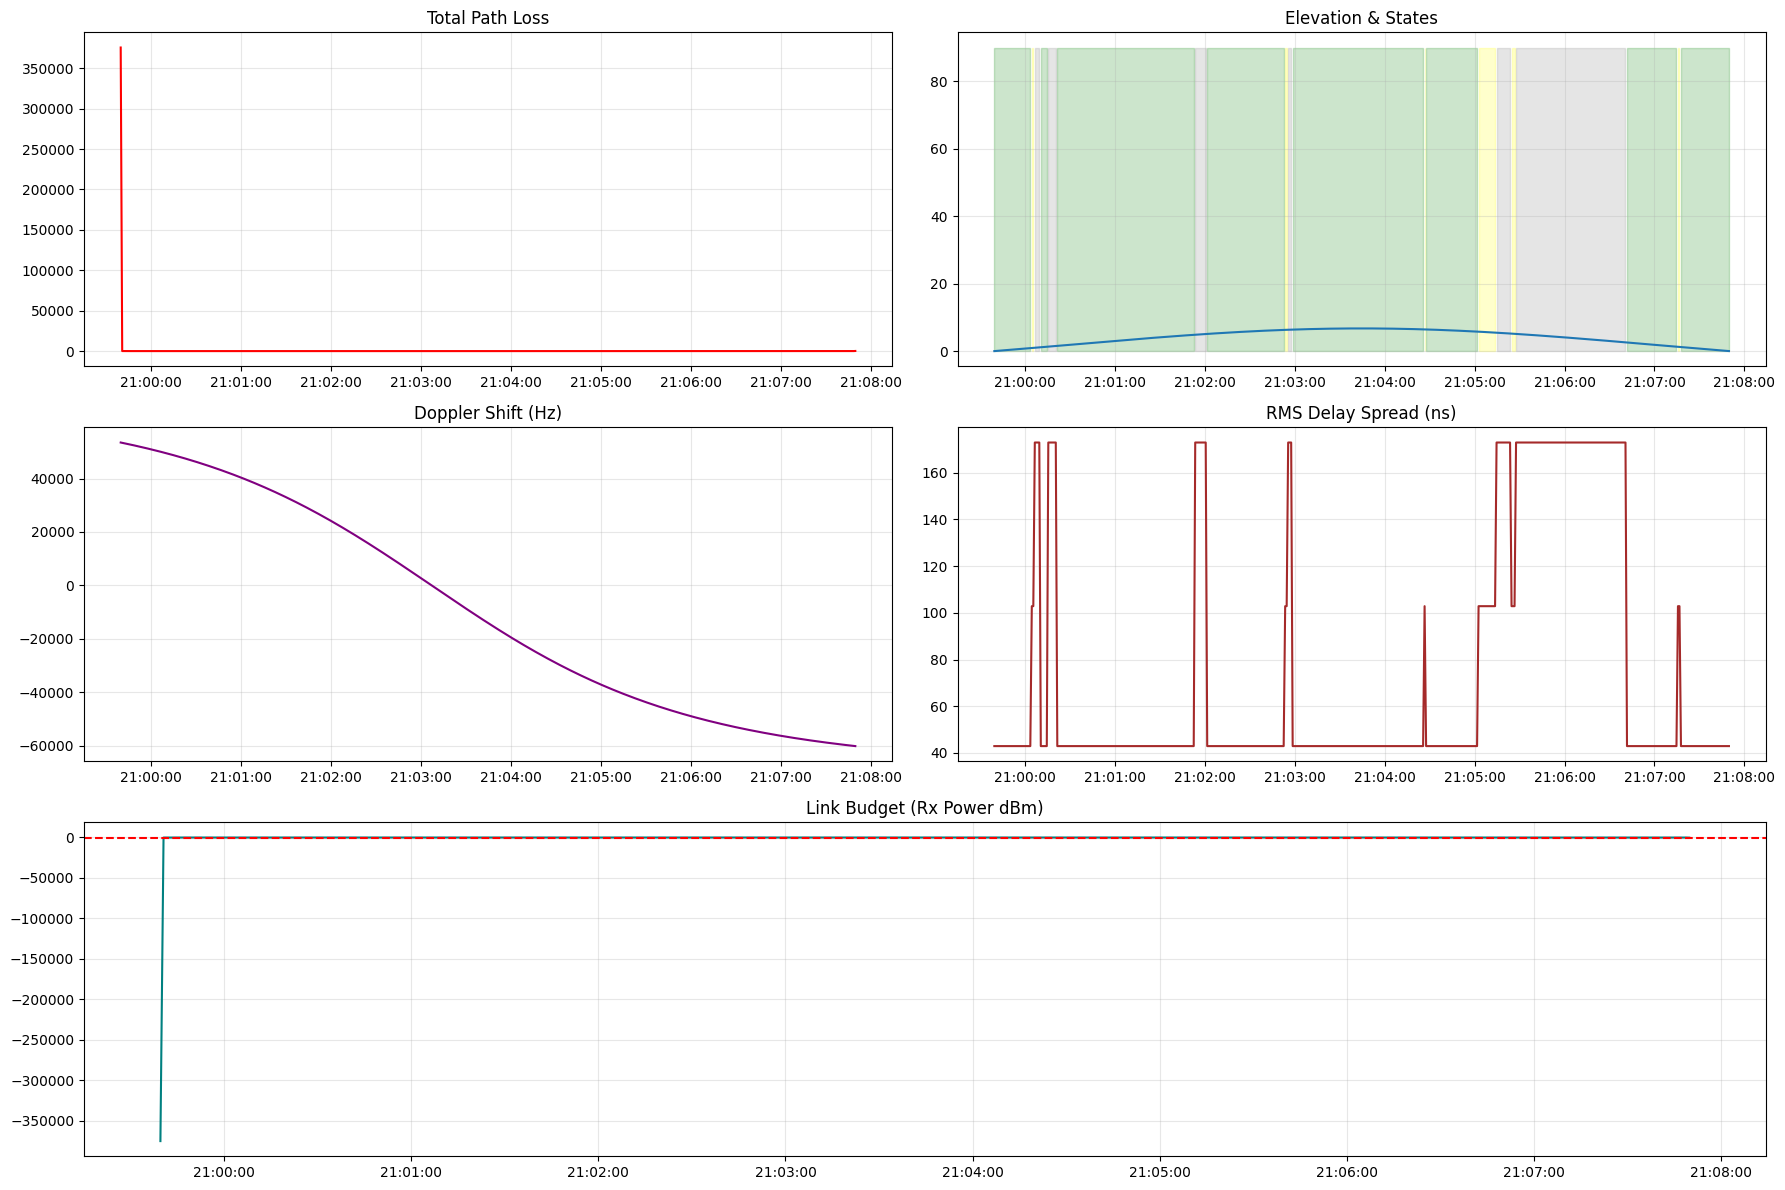

In [ ]:
import numpy as np
from datetime import datetime, timedelta
import collections
import warnings
import ephem
from sgp4.api import Satrec, SGP4_ERRORS
from astropy.time import Time
from astropy import units as u
from astropy.coordinates import TEME, ITRS, EarthLocation, CartesianRepresentation, CartesianDifferential

# ITU-R Zayıflama Modelleri
import itur
from itur.models.itu676 import gaseous_attenuation_slant_path as itu676
from itur.models.itu618 import rain_attenuation, scintillation_attenuation
from itur.models.itu840 import cloud_attenuation

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# ==========================================
# 1. PARAMETRE SETİ
# ==========================================
c = 299792458.0

gs_lat_deg = 39.9
gs_lon_deg = 32.8
gs_h_km = 0.850

station = ephem.Observer()
station.lat, station.lon = str(gs_lat_deg), str(gs_lon_deg)
station.elevation = gs_h_km * 1000.0

f_ghz = 3.0
f_hz = f_ghz * 1e9

T_k = 293.15
P_hpa = 1013.25
rho_gm3 = 7.5
p = 0.01
D = 0.6

tx_power_dbm = 40.0
tx_gain_dbi = 20.0
rx_gain_dbi = 0.0
rx_sensitivity_dbm = -125.0

tle_l1 = "1 64555U 25135AD  26106.74795786  .00001933  00000+0  92239-4 0  9993"
tle_l2 = "2 64555  97.4610 222.4026 0001997 124.5460 235.5964 15.20264790 45526"

sat = ephem.readtle("CONNECTA IOT-10", tle_l1, tle_l2)
sat_sgp4 = Satrec.twoline2rv(tle_l1, tle_l2)

# ==========================================
# 2. FİZİKSEL KATMAN VE KANAL FONKSİYONLARI
# ==========================================
def get_small_scale_loss(state):
    if state == 0:
        K = 10**(10/10)
        r = np.sqrt(K/(K+1)) + np.sqrt(1/(K+1)) * (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r))
    elif state == 1:
        r = (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r)) + 4.0
    else:
        r = (np.random.normal(0,1) + 1j*np.random.normal(0,1)) / np.sqrt(2)
        return -20 * np.log10(np.abs(r)) + 20.0

def get_transition_matrix(theta):
    theta_clamped = max(0, min(theta, 90))
    p_stay_los = 0.95 + 0.04 * (theta_clamped / 90)
    p_stay_blocked = 0.95 - 0.10 * (theta_clamped / 90)
    P = np.array([[p_stay_los, (1 - p_stay_los) * 0.8, (1 - p_stay_los) * 0.2],[0.05, 0.90, 0.05],[(1 - p_stay_blocked) * 0.8, (1 - p_stay_blocked) * 0.2, p_stay_blocked]])
    return P / P.sum(axis=1, keepdims=True)

def update_correlated_shadow(prev_shadow_db, theta, state):
    if state == 1:
        mu = 8.0 - (max(theta, 0.0) / 90.0) * 4.0
        innovation = np.random.normal(0.0, 3.0)
        return 0.985 * prev_shadow_db + np.sqrt(1 - 0.985**2) * innovation + mu
    return 0.0

def build_tdl_channel(state, theta, base_doppler_hz, propagation_delay_s):
    if state == 0:
        excess = np.array([0.0, 80e-9, 220e-9])
        pwr = np.array([1.0, 0.158, 0.031])
    elif state == 1:
        excess = np.array([0.0, 120e-9, 350e-9])
        pwr = np.array([1.0, 0.316, 0.125])
    else:
        excess = np.array([0.0, 180e-9, 500e-9])
        pwr = np.array([1.0, 0.5, 0.25])
    pwr /= pwr.sum()
    rms_ds = np.sqrt(np.sum(pwr * (excess)**2) - (np.sum(pwr * excess))**2)
    return (propagation_delay_s + excess), rms_ds

def doppler(satrec_obj, obs_time_dt, gs_lat_deg, gs_lon_deg, gs_h_km, f_hz):
    t = Time(obs_time_dt)
    error_code, teme_p, teme_v = satrec_obj.sgp4(t.jd1, t.jd2)
    teme = TEME(CartesianRepresentation(teme_p * u.km).with_differentials(CartesianDifferential(teme_v * u.km / u.s)), obstime=t)
    itrs_geo = teme.transform_to(ITRS(obstime=t))
    gs = EarthLocation.from_geodetic(lon=gs_lat_deg*u.deg, lat=gs_lat_deg*u.deg, height=gs_h_km*u.km)
    sat_pos = itrs_geo.cartesian.without_differentials().xyz.to(u.km).value
    sat_vel = itrs_geo.cartesian.differentials['s'].d_xyz.to(u.km/u.s).value
    gs_pos = gs.get_itrs(t).cartesian.xyz.to(u.km).value
    los = sat_pos - gs_pos
    v_rad = np.dot(sat_vel, los / np.linalg.norm(los)) * 1000.0
    return -v_rad / 299792458.0 * f_hz

# ==========================================
# 3. SİMÜLASYON
# ==========================================
station.date = datetime.utcnow()
pass_info = station.next_pass(sat)
rise_time, _, _, max_alt, set_time, _ = pass_info

print(f"--- GEÇİŞ BULUNDU ---\nBaşlangıç: {rise_time.datetime()} UTC\nMaksimum Elevasyon: {np.degrees(float(max_alt)):.1f} Derece")

data = collections.defaultdict(list)
station.date = rise_time
current_state = 0
shadow_corr_db = 0.0

while station.date < set_time:
    sat.compute(station)
    theta = np.degrees(float(sat.alt))
    dist_km = float(sat.range) / 1000.0
    if theta < 0: break

    current_state = np.random.choice([0, 1, 2], p=get_transition_matrix(theta)[current_state])

    # FSPL Standard formula
    fspl_db = 32.44 + 20 * np.log10(dist_km) + 20 * np.log10(f_ghz * 1000.0)

    try:
        gas_db = float(itu676(f_ghz, theta, rho_gm3, P_hpa, T_k, gs_h_km, mode='approx').value)
        rain_db = float(rain_attenuation(gs_lat_deg, gs_lon_deg, f_ghz, theta, p).value)
        atm_db = gas_db + rain_db
    except:
        atm_db = 0.5 / np.sin(np.radians(max(theta, 1.0)))

    shadow_corr_db = update_correlated_shadow(shadow_corr_db, theta, current_state)
    total_loss_db = fspl_db + atm_db + shadow_corr_db + get_small_scale_loss(current_state)

    _, rms_ds = build_tdl_channel(current_state, theta, 0, dist_km*1000/c)

    data['time'].append(station.date.datetime())
    data['theta'].append(theta)
    data['loss'].append(total_loss_db)
    data['doppler'].append(doppler(sat_sgp4, station.date.datetime(), gs_lat_deg, gs_lon_deg, gs_h_km, f_hz))
    data['rx_power'].append(tx_power_dbm + tx_gain_dbi + rx_gain_dbi - total_loss_db)
    data['state'].append(current_state)
    data['rms_ds_ns'].append(rms_ds * 1e9)
    station.date += ephem.second

# ==========================================
# 4. DASHBOARD
# ==========================================
time_arr = np.array(data['time'])
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time_arr, data['loss'], color='red')
ax1.set_title("Total Path Loss")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(time_arr, data['theta'])
ax2.set_title("Elevation & States")
for s, c_val in zip([0,1,2], ['green','yellow','gray']):
    ax2.fill_between(time_arr, 0, 90, where=(np.array(data['state'])==s), color=c_val, alpha=0.2)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(time_arr, data['doppler'], color='purple')
ax3.set_title("Doppler Shift (Hz)")

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(time_arr, data['rms_ds_ns'], color='brown')
ax4.set_title("RMS Delay Spread (ns)")

ax5 = fig.add_subplot(gs[2, :])
ax5.plot(time_arr, data['rx_power'], color='teal')
ax5.axhline(rx_sensitivity_dbm, color='red', linestyle='--')
ax5.fill_between(time_arr, -150, rx_sensitivity_dbm, color='red', alpha=0.1)
ax5.set_title("Link Budget (Rx Power dBm)")

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()